In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt


from sklearn.metrics import (mean_absolute_error,mean_squared_error)

df = pd.read_csv("../data/processed/processed_data.csv")

df["Date"] = pd.to_datetime(df["Date"])



# ETS USING statsforecast

In [2]:
# pip install statsforecast

In [3]:
from statsforecast import StatsForecast
from statsforecast.models import AutoETS, Naive, SeasonalNaive, ADIDA

# --- pipeline settings (same for Fixes B, D, E, A) ---
SPLIT_DATE = "2012-03-01"
FREQ = "W-FRI"
SEASON_LENGTH = 52
Y_FLOOR = 0.1

# tier rules (Fix D)
MEAN_SALES_THRESHOLD = 200
ZERO_PCT_THRESHOLD = 0.30   # 30% of weeks at/below 0.11

# metric buckets (Fix A)
FORECASTABLE_MEAN = 200
FORECASTABLE_ZERO_PCT = 30

In [4]:
# df_new= df.dropna().copy()
df_new=df.copy()

In [5]:
df_new.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Year,Month,Week,Temperature,Fuel_Price,...,Lag_2,Lag_4,Lag_8,Lag_52,Sales_Roll_Mean_4,Sales_Roll_Std_4,Sales_Roll_Mean_12,Sales_Roll_Std_12,Sales_EMA_4,Sales_EMA_12
0,1,1,2010-02-05,24924.50,0,2010,2,5,42.31,2.572,...,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,NaN,NaN
1,1,1,2010-02-12,46039.49,1,2010,2,6,38.51,2.548,...,NaN,NaN,NaN,NaN,24924.500000,0.000000,24924.500000,0.000000,24924.50000,24924.500000
2,1,1,2010-02-19,41595.55,0,2010,2,7,39.93,2.514,...,24924.50,NaN,NaN,NaN,35481.995000,14930.552614,35481.995000,14930.552614,33370.49600,28172.960000
3,1,1,2010-02-26,19403.54,0,2010,2,8,46.63,2.561,...,46039.49,NaN,NaN,NaN,37519.846667,11131.900957,37519.846667,11131.900957,36660.51760,30237.973846
4,1,1,2010-03-05,21827.90,0,2010,3,9,46.50,2.625,...,41595.55,24924.5,NaN,NaN,32990.770000,12832.106391,32990.770000,12832.106391,29757.72656,28571.137870


In [6]:
df_new.nunique()

Store                     45
Dept                      81
Date                     143
Weekly_Sales          359464
IsHoliday                  2
Year                       3
Month                     12
Week                      52
Temperature             3528
Fuel_Price               892
MarkDown1               2278
MarkDown2               1499
MarkDown3               1662
MarkDown4               1945
MarkDown5               2294
CPI                     2145
Unemployment             349
Size                      40
Type_A                     2
Type_B                     2
Type_C                     2
Lag_1                 357067
Lag_2                 354680
Lag_4                 349906
Lag_8                 340356
Lag_52                232997
Sales_Roll_Mean_4     397868
Sales_Roll_Std_4      413459
Sales_Roll_Mean_12    409714
Sales_Roll_Std_12     414145
Sales_EMA_4           417882
Sales_EMA_12          417948
dtype: int64

In [7]:
df_new.shape

(421570, 32)

In [8]:
df_new = df_new.rename(columns={"Store":"store","Dept":"dept","Date":"ds","Weekly_Sales":"y"})

In [9]:
df_new["unique_id"] = (df_new["store"].astype(str)+ "_"+ df_new["dept"].astype(str))


In [10]:
df_new = df_new[["unique_id","ds","y"]]
df_new.head()

,unique_id,ds,y
0,1_1,2010-02-05,24924.50
1,1_1,2010-02-12,46039.49
2,1_1,2010-02-19,41595.55
3,1_1,2010-02-26,19403.54
4,1_1,2010-03-05,21827.90


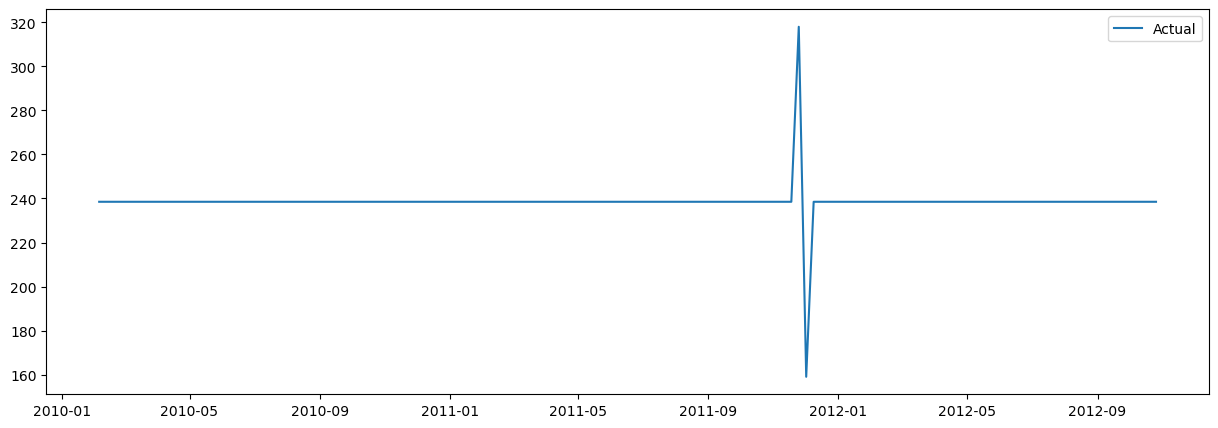

In [52]:
sample = "16_77"

actual = df_new[
    df_new["unique_id"] == sample
]

plt.figure(figsize=(15,5))

plt.plot(
    actual["ds"],
    actual["y"],
    label="Actual"
)

# plt.plot(
#     actual["ds"],
#     actual["AutoETS"],
#     label="autoETS Forecast"
# )

plt.legend()

plt.show()

In [12]:
# # 1. Generate the complete calendar index (weekly on Fridays)
# all_dates = pd.date_range(start=df_new['ds'].min(), end=df_new['ds'].max(), freq='W-FRI')
# uids = df_new['unique_id'].unique()
# full_index = pd.MultiIndex.from_product([uids, all_dates], names=['unique_id', 'ds'])

# # 2. Reindex df_new to insert all missing weeks, filling them with 0.1 sales
# df_new = df_new.set_index(['unique_id', 'ds']).reindex(full_index, fill_value=0.1).reset_index()

# # 3. Print the new shape to confirm gaps are filled
# print(f"Data cleaned and filled. New shape: {df_new.shape}")


In [45]:
# Fix B: reindex missing weeks, then forward/back fill PER SERIES (not 0.1 everywhere)
all_dates = pd.date_range(start=df_new["ds"].min(), end=df_new["ds"].max(), freq=FREQ)
uids = df_new["unique_id"].unique()
full_index = pd.MultiIndex.from_product([uids, all_dates], names=["unique_id", "ds"])

df_new = (df_new.set_index(["unique_id", "ds"]).reindex(full_index).reset_index())

# ffill → bfill within each series, then clip (same idea as notebook clip step)
# df_new["y"] = df_new.groupby("unique_id")["y"].transform(
#     lambda s: s.fillna(s.mean())
# )
df_new["y"] = df_new.groupby("unique_id")["y"].transform(lambda s: s.ffill().bfill())
# df_new["y"] = df_new["y"].clip(lower=Y_FLOOR)

print(f"Data cleaned and filled. New shape: {df_new.shape}")
print(f"Rows still missing y: {df_new['y'].isna().sum()}")

Data cleaned and filled. New shape: (476333, 3)
Rows still missing y: 0


In [53]:
# Sanity check: compare old vs new for one bad series
sample_uid = "16_77"
before_style = df_new[df_new["unique_id"] == sample_uid].head(15)[["ds", "y"]]
print(before_style)
print(f"Zero/low weeks (%): {(df_new['y'] <= 0.11).mean() * 100:.1f}%")

               ds      y
171743 2010-02-05  238.5
171744 2010-02-12  238.5
171745 2010-02-19  238.5
171746 2010-02-26  238.5
171747 2010-03-05  238.5
171748 2010-03-12  238.5
171749 2010-03-19  238.5
171750 2010-03-26  238.5
171751 2010-04-02  238.5
171752 2010-04-09  238.5
171753 2010-04-16  238.5
171754 2010-04-23  238.5
171755 2010-04-30  238.5
171756 2010-05-07  238.5
171757 2010-05-14  238.5
Zero/low weeks (%): 1.5%


In [47]:
df_new["unique_id"].nunique()

3331

In [48]:
df_new[df_new["y"]<0]

,unique_id,ds,y
846,1_6,2012-08-10,-139.650000
2405,1_18,2012-05-04,-1.270000
6150,1_47,2010-02-12,-116.454545
6151,1_47,2010-02-19,-863.000000
6152,1_47,2010-02-26,-116.454545
...,...,...,...
474189,45_80,2010-02-12,-0.430000
474190,45_80,2010-02-19,-0.270000
474198,45_80,2010-04-16,-1.610000
474209,45_80,2010-07-02,-0.270000


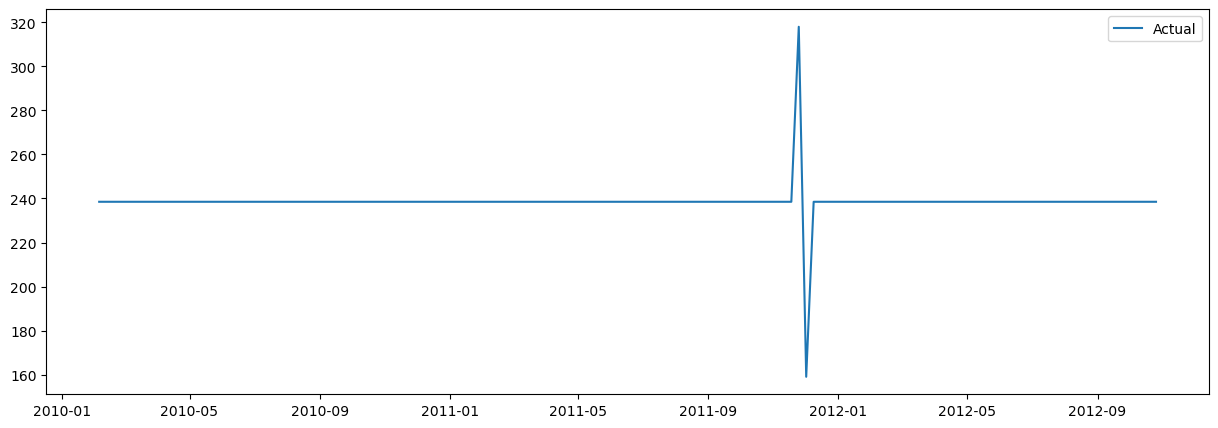

In [51]:
sample = "16_77"

actual = df_new[
    df_new["unique_id"] == sample
]

plt.figure(figsize=(15,5))

plt.plot(
    actual["ds"],
    actual["y"],
    label="Actual"
)

# plt.plot(
#     actual["ds"],
#     actual["AutoETS"],
#     label="autoETS Forecast"
# )

plt.legend()

plt.show()

In [18]:
# # split_date = "2012-03-01"

# # # 1. Split into train and valid
# # train = df_new[df_new.ds <= split_date].copy()
# # valid = df_new[df_new.ds > split_date].copy()

# split_date = "2012-03-01"

# # 1. Filter the dataset to only evaluate the clean series "1_1"
# df_sample = df_new[df_new['unique_id'] == '1_1'].copy()

# # 2. Split into train and valid sets
# train = df_sample[df_sample.ds <= split_date].copy()
# valid = df_sample[df_sample.ds > split_date].copy()


# # # 2. Filter out non-positive sales (since ETS cannot handle zero or negative values)
# # train = train[train['y'] > 0.1]

# # 3. Filter out series with fewer than 56 data points in the training set (needed for seasonality of 52)
# train_counts = train.groupby('unique_id').size()
# valid_series = train_counts[train_counts >= 56].index
# train = train[train['unique_id'].isin(valid_series)]

# # 4. Filter out constant series (zeros or identical numbers, which cause division by zero in optimization)
# train_vars = train.groupby('unique_id')['y'].var()
# active_series = train_vars[train_vars > 0.01].index
# train = train[train['unique_id'].isin(active_series)]

# # 5. Ensure valid set only contains series that we actually trained on
# valid = valid[valid['unique_id'].isin(train['unique_id'].unique())]


In [19]:
# split_date = "2012-03-01"
## 1 store all dept
# # 1. Filter for all departments in Store 1 (starts with '1_')
# df_sample = df_new[df_new['unique_id'].str.startswith('1_')].copy()

# # 2. Split into train and valid sets
# train = df_sample[df_sample.ds <= split_date].copy()
# valid = df_sample[df_sample.ds > split_date].copy()

# # 3. Clip negative/zero sales to 0.1 (preserves the timeline and supports log/additive math)
# train['y'] = train['y'].clip(lower=0.1)

# # 4. Filter out series with fewer than 56 data points in the training set
# train_counts = train.groupby('unique_id').size()
# valid_series = train_counts[train_counts >= 56].index
# train = train[train['unique_id'].isin(valid_series)]

# # 5. Filter out constant series (variance close to zero)
# train_vars = train.groupby('unique_id')['y'].var()
# active_series = train_vars[train_vars > 0.01].index
# train = train[train['unique_id'].isin(active_series)]

# # 6. Align valid set
# valid = valid[valid['unique_id'].isin(train['unique_id'].unique())]


In [20]:
split_date = "2012-03-01"
# whole dataset
# 1. Split into train and valid sets for the whole dataset
train = df_new[df_new.ds <= split_date].copy()
valid = df_new[df_new.ds > split_date].copy()

# 2. Clip negative/zero sales to 0.1
# train['y'] = train['y'].clip(lower=0.1)


# 3. Filter out series with fewer than 56 data points in the training set
train_counts = train.groupby('unique_id').size()
valid_series = train_counts[train_counts >= 56].index
train = train[train['unique_id'].isin(valid_series)]

# 4. Filter out constant series (variance close to zero)
train_vars = train.groupby('unique_id')['y'].var()
active_series = train_vars[train_vars > 0.01].index
train = train[train['unique_id'].isin(active_series)]

# 5. Align valid set
valid = valid[valid['unique_id'].isin(train['unique_id'].unique())]


In [21]:
train

,unique_id,ds,y
0,1_1,2010-02-05,24924.50
1,1_1,2010-02-12,46039.49
2,1_1,2010-02-19,41595.55
3,1_1,2010-02-26,19403.54
4,1_1,2010-03-05,21827.90
...,...,...,...
476293,45_98,2012-01-27,671.40
476294,45_98,2012-02-03,772.51
476295,45_98,2012-02-10,770.86
476296,45_98,2012-02-17,889.98


In [22]:
# sf = StatsForecast(models=[AutoETS(season_length=52, model="AAA")],freq="W-FRI",n_jobs=-1)

In [23]:
from statsforecast import StatsForecast
from statsforecast.models import AutoETS, Naive

# 1. Instantiate StatsForecast with Naive as the fallback
sf = StatsForecast(
    models=[AutoETS(season_length=52, model="AAA")],
    freq="W-FRI",
    fallback_model=Naive(),  # If AutoETS fails on any of the 3,000 series, use Naive instead
    n_jobs=-1
)

# 2. Fit the model on the whole dataset
sf.fit(train)
print("Fitting completed successfully for the entire dataset!")


Fitting completed successfully for the entire dataset!


In [24]:
# sf.fit(train)

In [25]:
h = valid["ds"].nunique()

In [26]:
forecast = sf.predict(h=h)
forecast.head()

,unique_id,ds,AutoETS
0,10_1,2012-03-02,33360.356535
1,10_1,2012-03-09,33248.847504
2,10_1,2012-03-16,35001.745917
3,10_1,2012-03-23,48414.304775
4,10_1,2012-03-30,91617.032313


In [27]:
forecast

,unique_id,ds,AutoETS
0,10_1,2012-03-02,33360.356535
1,10_1,2012-03-09,33248.847504
2,10_1,2012-03-16,35001.745917
3,10_1,2012-03-23,48414.304775
4,10_1,2012-03-30,91617.032313
...,...,...,...
114760,9_98,2012-09-28,28.508422
114761,9_98,2012-10-05,28.515692
114762,9_98,2012-10-12,27.127974
114763,9_98,2012-10-19,27.379842


In [28]:
valid

,unique_id,ds,y
108,1_1,2012-03-02,20113.03
109,1_1,2012-03-09,21140.07
110,1_1,2012-03-16,22366.88
111,1_1,2012-03-23,22107.70
112,1_1,2012-03-30,28952.86
...,...,...,...
476328,45_98,2012-09-28,508.37
476329,45_98,2012-10-05,628.10
476330,45_98,2012-10-12,1061.02
476331,45_98,2012-10-19,760.01


In [29]:
results = valid.merge(forecast,on=["unique_id","ds"])
print(results)

       unique_id         ds         y       AutoETS
0            1_1 2012-03-02  20113.03  20165.117858
1            1_1 2012-03-09  21140.07  19454.240400
2            1_1 2012-03-16  22366.88  20485.404823
3            1_1 2012-03-23  22107.70  24484.365453
4            1_1 2012-03-30  28952.86  49859.370860
...          ...        ...       ...           ...
114760     45_98 2012-09-28    508.37   1177.591456
114761     45_98 2012-10-05    628.10   1240.540669
114762     45_98 2012-10-12   1061.02   1246.232587
114763     45_98 2012-10-19    760.01   1361.566414
114764     45_98 2012-10-26   1076.80   1384.041313

[114765 rows x 4 columns]


In [30]:
mae = np.mean(np.abs(results["y"] -results["AutoETS"]))
print(mae)

1584.5672407824147


In [31]:
rmse = np.sqrt(np.mean((results["y"]-results["AutoETS"])**2))
print(rmse)

3364.332192297385


In [32]:
wmape = (np.abs(results["y"]-results["AutoETS"]).sum()/np.abs(results["y"]).sum())*100
print(wmape)
print("Accuracy:",100-wmape)

11.071198056934936
Accuracy: 88.92880194306507


In [33]:
# 1. Generate a complete weekly date range from the start to the end of the dataset
all_dates = pd.date_range(start=df_new['ds'].min(), end=df_new['ds'].max(), freq='W-FRI')
uids = df_new['unique_id'].unique()

# 2. Create a complete Multi-Index of all combinations of unique_id and date
full_index = pd.MultiIndex.from_product([uids, all_dates], names=['unique_id', 'ds'])

# 3. Reindex the dataset. Any missing weeks will be filled with NaN in the sales column 'y'
df_reindexed = df_new.set_index(['unique_id', 'ds']).reindex(full_index).reset_index()

# 4. Filter for the rows that were missing in the original data
missing_weeks = df_reindexed[df_reindexed['y'].isna()]

print(f"Total missing weeks (gaps in timeline): {len(missing_weeks)}")
if len(missing_weeks) > 0:
    print("\nSample of missing weeks (gaps):")
    print(missing_weeks.head(10))


Total missing weeks (gaps in timeline): 0


In [34]:
# Retrieve the fitted models and unique IDs from statsforecast
fitted_models = sf.fitted_
uids = sf.uids  # Corrected from sf.ga.uids to sf.uids

ets_count = 0
fallback_count = 0
failed_series = []

for i, uid in enumerate(uids):
    # Get the fitted model object for each series
    model_obj = fitted_models[i, 0]
    model_name = type(model_obj).__name__
    
    # Check if the fitted model is an ETS model
    if 'ETS' in model_name:
        ets_count += 1
    else:
        fallback_count += 1
        failed_series.append(uid)

print("--- FALLBACK USAGE REPORT ---")
print(f"Total time series:                  {len(uids)}")
print(f"Successfully fitted with AutoETS:   {ets_count} ({ets_count/len(uids)*100:.2f}%)")
print(f"Felled back to Naive:               {fallback_count} ({fallback_count/len(uids)*100:.2f}%)")

if fallback_count > 0:
    print(f"\nSample of series that used the fallback model (showing first 10 out of {fallback_count}):")
    print(failed_series[:10])


--- FALLBACK USAGE REPORT ---
Total time series:                  3279
Successfully fitted with AutoETS:   3279 (100.00%)
Felled back to Naive:               0 (0.00%)


In [35]:
# 1. Extract the training data for the failed series
anomaly_data = train[train['unique_id'] == '13_51'].sort_values('ds')

# 2. Print key mathematical characteristics
print(f"Total weeks of data: {len(anomaly_data)}")
print(f"Variance of sales:   {anomaly_data['y'].var():.4f}")
print(f"Mean of sales:       {anomaly_data['y'].mean():.4f}")
print(f"Number of zeros/0.1: {anomaly_data[anomaly_data['y'] <= 0.11].shape[0]}")
print("\nFirst 15 weeks of sales:")
print(anomaly_data.head(15)[['ds', 'y']])


Total weeks of data: 108
Variance of sales:   581.5902
Mean of sales:       21.5312
Number of zeros/0.1: 5

First 15 weeks of sales:
               ds      y
136851 2010-02-05  31.58
136852 2010-02-12  25.04
136853 2010-02-19  14.00
136854 2010-02-26  55.52
136855 2010-03-05  23.38
136856 2010-03-12  18.00
136857 2010-03-19  71.00
136858 2010-03-26  65.32
136859 2010-04-02  14.16
136860 2010-04-09 -14.56
136861 2010-04-16  23.64
136862 2010-04-23  10.52
136863 2010-04-30   1.00
136864 2010-05-07  11.08
136865 2010-05-14   6.52


In [36]:
# See the training data for one of the failed series
train[train['unique_id'] == '29_51']


,unique_id,ds,y
313456,29_51,2010-02-05,3.000000
313457,29_51,2010-02-12,47.880000
313458,29_51,2010-02-19,5.000000
313459,29_51,2010-02-26,35.200000
313460,29_51,2010-03-05,45.520000
...,...,...,...
313559,29_51,2012-01-27,20.110877
313560,29_51,2012-02-03,20.110877
313561,29_51,2012-02-10,20.110877
313562,29_51,2012-02-17,20.110877


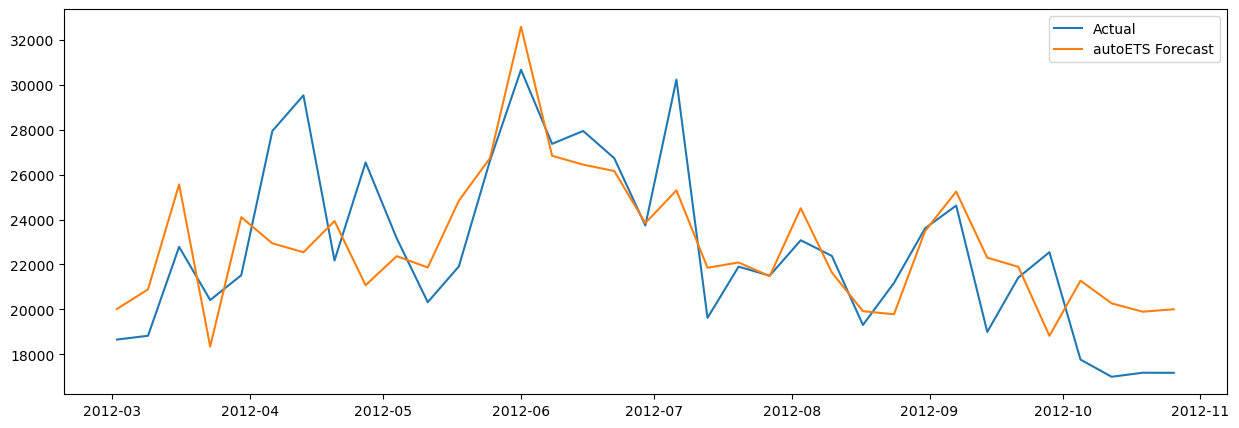

In [37]:
sample = "39_9"

actual = results[
    results["unique_id"] == sample
]

plt.figure(figsize=(15,5))

plt.plot(
    actual["ds"],
    actual["y"],
    label="Actual"
)

plt.plot(
    actual["ds"],
    actual["AutoETS"],
    label="autoETS Forecast"
)

plt.legend()

plt.show()

In [38]:
# 1. Define a helper function to calculate wMAPE for each series
def calculate_series_wmape(group):
    actual = group['y']
    predicted = group['AutoETS']  # Using the AutoETS predictions
    
    # Avoid division by zero if sales are zero/0.1
    if actual.sum() <= 5: 
        return np.nan
        
    return (np.abs(actual - predicted).sum() / actual.sum()) * 100

# 2. Group by unique_id and apply the wMAPE calculation
series_errors = results.groupby('unique_id').apply(calculate_series_wmape).reset_index(name='wmape')

# 3. Sort by wmape in descending order
worst_series = series_errors.dropna().sort_values(by='wmape', ascending=False)

print("--- WORST PERFORMING STORE-DEPARTMENTS (Highest wMAPE) ---")
print(worst_series.head(15).to_string(index=False))


--- WORST PERFORMING STORE-DEPARTMENTS (Highest wMAPE) ---
unique_id       wmape
    35_80 3352.513907
    27_47 1549.446529
    10_59  739.693220
     2_47  643.205751
    22_94  584.931863
    11_47  563.415014
     4_47  493.710831
    23_54  460.221685
    28_59  459.647240
     1_59  417.117990
    20_54  399.911474
    11_54  399.670967
    31_99  396.311715
    18_96  395.371922
    20_99  373.051049


In [39]:
worst_series

,unique_id,wmape
2083,35_80,3352.513907
1406,27_47,1549.446529
49,10_59,739.693220
1636,2_47,643.205751
1058,22_94,584.931863
...,...,...
3260,9_77,0.035299
2006,34_77,0.035299
511,16_77,0.011075
1273,25_77,0.011075


In [40]:
worst_series[worst_series["wmape"]>100]

,unique_id,wmape
2083,35_80,3352.513907
1406,27_47,1549.446529
49,10_59,739.693220
1636,2_47,643.205751
1058,22_94,584.931863
...,...,...
2669,43_52,104.029471
1703,30_41,103.652581
961,21_58,102.864732
1957,34_18,101.640718


In [41]:
def diagnose_series(uid, train, results):
    t = train[train["unique_id"] == uid]
    r = results[results["unique_id"] == uid]
    
    return {
        "unique_id": uid,
        "mean_sales": t["y"].mean(),
        "zero_pct": (t["y"] <= 0.11).mean() * 100,
        "cv": t["y"].std() / t["y"].mean() if t["y"].mean() > 0 else np.nan,
        "wmape": (np.abs(r["y"] - r["AutoETS"]).sum() / r["y"].sum()) * 100,
    }

# Run for top 20 worst
worst_ids = worst_series.head(20)["unique_id"].tolist()
diag = pd.DataFrame([diagnose_series(uid, train, results) for uid in worst_ids])
print(diag.sort_values("wmape", ascending=False))

   unique_id   mean_sales   zero_pct         cv        wmape
0      35_80    66.210486   7.407407   1.182575  3352.513907
1      27_47     6.992552   9.259259  10.259602  1549.446529
2      10_59  2568.555833   0.000000   2.417937   739.693220
3       2_47    17.384891   6.481481  15.474982   643.205751
4      22_94  1075.764231   0.925926   1.126073   584.931863
5      11_47    -0.725556   6.481481        NaN   563.415014
6       4_47    26.513340   2.777778   4.965923   493.710831
7      23_54   298.166759   0.000000   1.018870   460.221685
8      28_59  1055.985278   0.000000   2.169581   459.647240
9       1_59  1077.880370   0.000000   1.966936   417.117990
10     20_54   276.126296   1.851852   0.846042   399.911474
11     11_54   297.020833   1.851852   1.020318   399.670967
12     31_99   258.821901  10.185185   1.771209   396.311715
13     18_96     0.150957   2.777778  50.775596   395.371922
14     20_99   948.810741   1.851852   1.363506   373.051049
15      6_59  1268.04092

In [42]:
worst_ids

['35_80',
 '27_47',
 '10_59',
 '2_47',
 '22_94',
 '11_47',
 '4_47',
 '23_54',
 '28_59',
 '1_59',
 '20_54',
 '11_54',
 '31_99',
 '18_96',
 '20_99',
 '6_59',
 '8_59',
 '2_59',
 '35_54',
 '41_51']

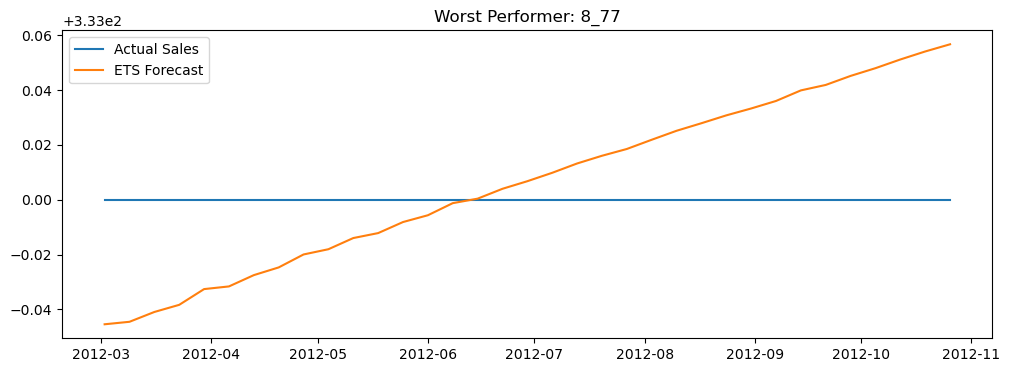

In [43]:
# Plot the worst series (replace 'Store_Dept' with a unique_id from the printed list, e.g. '1_18')
bad_uid = '8_77' 
actual_bad = results[results["unique_id"] == bad_uid]

plt.figure(figsize=(12, 4))
plt.plot(actual_bad["ds"], actual_bad["y"], label="Actual Sales")
plt.plot(actual_bad["ds"], actual_bad["AutoETS"], label="ETS Forecast")
plt.title(f"Worst Performer: {bad_uid}")
plt.legend()
plt.show()


In [44]:
# go through my 05_Model_Comparison.ipynb . i am facing one issue where some of my store dept time series are not working properly . can you tell me how can i fix that 